In [11]:
import os
import torch
import time, datetime
from torch.autograd import Variable
from torch import optim
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from matplotlib import pyplot as plt
from datasets import load_dataset
import nest_asyncio; nest_asyncio.apply()

# Content

- testing the new weights vgg-normalised.pth used in stya2k and sanet to generate 10 images, i pick 2 content and 5 style pictures 

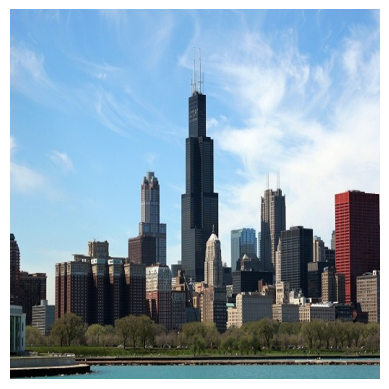

In [14]:
img_size = 512
prep = transforms.Compose([transforms.Resize(img_size),
                           transforms.ToTensor(),
                           transforms.Lambda(lambda x: x[torch.LongTensor([2,1,0])]), #turn to BGR
                           transforms.Normalize(mean=[0.40760392, 0.45795686, 0.48501961], #subtract imagenet mean
                                                std=[1,1,1]),
                           transforms.Lambda(lambda x: x.mul_(255)),
                          ])

content_path = "pictures_new_weights/content"
style_path = "pictures_new_weights/style"
output_path = "pictures_new_weights/output"

content_imgs = [Image.open(os.path.join(content_path, img)) for img in os.listdir(content_path)]
style_imgs = [Image.open(os.path.join(style_path, img)) for img in os.listdir(style_path)]
plt.imshow(content_imgs[0]); plt.axis('off'); plt.show()
content_imgs = [Variable(prep(img).unsqueeze(0).cuda()) for img in content_imgs]
style_imgs = [Variable(prep(img).unsqueeze(0).cuda()) for img in style_imgs]


Defining models

In [ ]:
class VGG(nn.Module):
    def __init__(self, pool='avg'):
        super(VGG, self).__init__()
        #vgg modules
        self.conv1_1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv3_3 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv3_4 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv4_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv4_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv4_3 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv4_4 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_1 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_3 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_4 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        if pool == 'max':
            self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)
        elif pool == 'avg':
            self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool3 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool4 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool5 = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x, out_keys):
        out = {}
        out['r11'] = F.relu(self.conv1_1(x))
        out['r12'] = F.relu(self.conv1_2(out['r11']))
        out['p1'] = self.pool1(out['r12'])

        out['r21'] = F.relu(self.conv2_1(out['p1']))
        out['r22'] = F.relu(self.conv2_2(out['r21']))
        out['p2'] = self.pool2(out['r22'])

        out['r31'] = F.relu(self.conv3_1(out['p2']))
        out['r32'] = F.relu(self.conv3_2(out['r31']))
        out['r33'] = F.relu(self.conv3_3(out['r32']))
        out['r34'] = F.relu(self.conv3_4(out['r33']))
        out['p3'] = self.pool3(out['r34'])

        out['r41'] = F.relu(self.conv4_1(out['p3']))
        out['r42'] = F.relu(self.conv4_2(out['r41']))
        out['r43'] = F.relu(self.conv4_3(out['r42']))
        out['r44'] = F.relu(self.conv4_4(out['r43']))
        out['p4'] = self.pool4(out['r44'])

        out['r51'] = F.relu(self.conv5_1(out['p4']))
        out['r52'] = F.relu(self.conv5_2(out['r51']))
        out['r53'] = F.relu(self.conv5_3(out['r52']))
        out['r54'] = F.relu(self.conv5_4(out['r53']))
        out['p5'] = self.pool5(out['r54'])
        
        return [out[key] for key in out_keys]

class GramMatrix(nn.Module):
    def forward(self, input):
        b,c,h,w = input.size()
        F = input.view(b, c, h*w)
        G = torch.bmm(F, F.transpose(1,2))
        G.div_(h*w)
        return G

class GramMSELoss(nn.Module):
    def forward(self, input, target):
        out = nn.MSELoss()(GramMatrix()(input), target)
        return(out)
    
class PearsonCorrelationLoss(nn.Module):
    def forward(self, x, y):
        """
        Pearson correlation loss.
        """
        
        x_gram = GramMatrix()(x)

        x_flat = x_gram.view(-1).float()
        y_flat = y.view(-1).float()

        mean_x = torch.mean(x_flat)
        mean_y = torch.mean(y_flat)

        xm = x_flat - mean_x
        ym = y_flat - mean_y

        numer = torch.dot(xm, ym)
        denom = torch.sqrt(torch.dot(xm, xm) * torch.dot(ym, ym))
        eps = 1e-8
        r = numer / (denom + eps)
        distance = 1.0 - r
        return (distance)

class CosineSimilarityLoss(nn.Module):
    def forward(self, x, y):
        """
        Cosine similarity loss.
        """
        x_gram = GramMatrix()(x)

        x_flat = x_gram.view(-1).float()
        y_flat = y.view(-1).float()
        # Dot‐product
        dot_xy = torch.dot(x_flat, y_flat)
        # Norme L2
        norm_x = torch.norm(x_flat, p=2)
        norm_y = torch.norm(y_flat, p=2)
        eps = 1e-8
        cos_sim = dot_xy / (norm_x * norm_y + eps)
        return (1.0 - cos_sim)


postpa = transforms.Compose([transforms.Lambda(lambda x: x.mul_(1./255)),
                           transforms.Normalize(mean=[-0.40760392, -0.45795686, -0.48501961], #add imagenet mean
                                                std=[1,1,1]),
                           transforms.Lambda(lambda x: x[torch.LongTensor([2,1,0])]), #turn to RGB
                           ])
postpb = transforms.Compose([transforms.ToPILImage()])

def postp(tensor): # to clip results in the range [0,1]
    t = postpa(tensor)
    t[t>1] = 1
    t[t<0] = 0
    img = postpb(t)
    return img

New Model

In [5]:
class new_VGG(nn.Module):
    def __init__(self):
        super().__init__()
        self.pre = nn.Conv2d(3, 3, (1, 1))

        self.pad1_1 = nn.ReflectionPad2d((1, 1, 1, 1))
        self.conv1_1 = nn.Conv2d(3, 64, (3, 3))
        self.pad1_2 = nn.ReflectionPad2d((1, 1, 1, 1))
        self.conv1_2 = nn.Conv2d(64, 64, (3, 3))
        self.pool1 = nn.MaxPool2d((2, 2), (2, 2), ceil_mode=True)

        self.pad2_1 = nn.ReflectionPad2d((1, 1, 1, 1))
        self.conv2_1 = nn.Conv2d(64, 128, (3, 3))
        self.pad2_2 = nn.ReflectionPad2d((1, 1, 1, 1))
        self.conv2_2 = nn.Conv2d(128, 128, (3, 3))
        self.pool2 = nn.MaxPool2d((2, 2), (2, 2), ceil_mode=True)

        self.pad3_1 = nn.ReflectionPad2d((1, 1, 1, 1))
        self.conv3_1 = nn.Conv2d(128, 256, (3, 3))
        self.pad3_2 = nn.ReflectionPad2d((1, 1, 1, 1))
        self.conv3_2 = nn.Conv2d(256, 256, (3, 3))
        self.pad3_3 = nn.ReflectionPad2d((1, 1, 1, 1))
        self.conv3_3 = nn.Conv2d(256, 256, (3, 3))
        self.pad3_4 = nn.ReflectionPad2d((1, 1, 1, 1))
        self.conv3_4 = nn.Conv2d(256, 256, (3, 3))
        self.pool3 = nn.MaxPool2d((2, 2), (2, 2), ceil_mode=True)

        self.pad4_1 = nn.ReflectionPad2d((1, 1, 1, 1))
        self.conv4_1 = nn.Conv2d(256, 512, (3, 3))
        self.pad4_2 = nn.ReflectionPad2d((1, 1, 1, 1))
        self.conv4_2 = nn.Conv2d(512, 512, (3, 3))
        self.pad4_3 = nn.ReflectionPad2d((1, 1, 1, 1))
        self.conv4_3 = nn.Conv2d(512, 512, (3, 3))
        self.pad4_4 = nn.ReflectionPad2d((1, 1, 1, 1))
        self.conv4_4 = nn.Conv2d(512, 512, (3, 3))
        self.pool4 = nn.MaxPool2d((2, 2), (2, 2), ceil_mode=True)

        self.pad5_1 = nn.ReflectionPad2d((1, 1, 1, 1))
        self.conv5_1 = nn.Conv2d(512, 512, (3, 3))
        self.pad5_2 = nn.ReflectionPad2d((1, 1, 1, 1))
        self.conv5_2 = nn.Conv2d(512, 512, (3, 3))
        self.pad5_3 = nn.ReflectionPad2d((1, 1, 1, 1))
        self.conv5_3 = nn.Conv2d(512, 512, (3, 3))
        self.pad5_4 = nn.ReflectionPad2d((1, 1, 1, 1))
        self.conv5_4 = nn.Conv2d(512, 512, (3, 3))
        self.pool5 = nn.MaxPool2d((2, 2), (2, 2), ceil_mode=True)

    def forward(self, x, out_keys):
        out = {}
        x = self.pre(x)

        out['r11'] = F.relu(self.conv1_1(self.pad1_1(x)))
        out['r12'] = F.relu(self.conv1_2(self.pad1_2(out['r11'])))
        out['p1']  = self.pool1(out['r12'])

        out['r21'] = F.relu(self.conv2_1(self.pad2_1(out['p1'])))
        out['r22'] = F.relu(self.conv2_2(self.pad2_2(out['r21'])))
        out['p2']  = self.pool2(out['r22'])

        out['r31'] = F.relu(self.conv3_1(self.pad3_1(out['p2'])))
        out['r32'] = F.relu(self.conv3_2(self.pad3_2(out['r31'])))
        out['r33'] = F.relu(self.conv3_3(self.pad3_3(out['r32'])))
        out['r34'] = F.relu(self.conv3_4(self.pad3_4(out['r33'])))
        out['p3']  = self.pool3(out['r34'])

        out['r41'] = F.relu(self.conv4_1(self.pad4_1(out['p3'])))
        out['r42'] = F.relu(self.conv4_2(self.pad4_2(out['r41'])))
        out['r43'] = F.relu(self.conv4_3(self.pad4_3(out['r42'])))
        out['r44'] = F.relu(self.conv4_4(self.pad4_4(out['r43'])))
        out['p4']  = self.pool4(out['r44'])

        out['r51'] = F.relu(self.conv5_1(self.pad5_1(out['p4'])))
        out['r52'] = F.relu(self.conv5_2(self.pad5_2(out['r51'])))
        out['r53'] = F.relu(self.conv5_3(self.pad5_3(out['r52'])))
        out['r54'] = F.relu(self.conv5_4(self.pad5_4(out['r53'])))
        out['p5']  = self.pool5(out['r54'])

        return [out[k] for k in out_keys]


Loading weigths

In [8]:
model_dir = './'

vgg_standard = VGG()
vgg_standard.load_state_dict(torch.load('vgg_conv.pth'))

for param in vgg_standard.parameters():
    param.requires_grad = False
if torch.cuda.is_available():
    vgg_standard.cuda()

vgg_newweights = new_VGG()
sd = torch.load("vgg_normalised.pth", map_location="cpu")
name2idx = {
    "pre": 0,
    "conv1_1": 2,  "conv1_2": 5,
    "conv2_1": 9,  "conv2_2": 12,
    "conv3_1": 16, "conv3_2": 19, "conv3_3": 22, "conv3_4": 25,
    "conv4_1": 29, "conv4_2": 32, "conv4_3": 35, "conv4_4": 38,
    "conv5_1": 42, "conv5_2": 45, "conv5_3": 48, "conv5_4": 51,
}
new_sd = vgg_newweights.state_dict()
for name, idx in name2idx.items():
    new_sd[f"{name}.weight"] = sd[f"{idx}.weight"]
    new_sd[f"{name}.bias"]   = sd[f"{idx}.bias"]

vgg_newweights.load_state_dict(new_sd, strict=True)

for param in vgg_newweights.parameters():
    param.requires_grad = False
if torch.cuda.is_available():
    vgg_newweights.cuda()

In [15]:
def synthesizeImage_modelpick(model, style_image, content_image, loss_fn, style_weights, content_weights, max_iter=500, show_iter=100):

    # Image to optimize is a clone of the content image for faster convergence
    opt_img = Variable(content_image.data.clone(), requires_grad=True)
    style_layers = ['r11','r21','r31','r41', 'r51']
    content_layers = ['r42']
    loss_layers = style_layers + content_layers

    # Here the used loss functions are instantiated (MSE, Pearson, Cosine)
    loss_fns = [loss_fn()] * len(style_layers) + [nn.MSELoss()] * len(content_layers)
    if torch.cuda.is_available():
        loss_fns = [loss_fn.cuda() for loss_fn in loss_fns]

    weights = style_weights + content_weights

    #compute optimization targets
    style_targets = [GramMatrix()(A).detach() for A in model(style_image, style_layers)]
    content_targets = [A.detach() for A in model(content_image, content_layers)]
    targets = style_targets + content_targets

    #run style transfer
    optimizer = optim.LBFGS([opt_img]) # LBFGS as in the original gatys implementation
    n_iter=[0]

    while n_iter[0] <= max_iter:

        def closure():
            optimizer.zero_grad()
            out = model(opt_img, loss_layers)
            layer_losses = [weights[a] * loss_fns[a](A, targets[a]) for a,A in enumerate(out)]
            loss = torch.sum(torch.stack(layer_losses))
            loss.backward()
            n_iter[0]+=1
            if n_iter[0] % show_iter == 0:
                print(f"Iteration {n_iter[0]}: Loss = {loss.item()}")
            return loss

        optimizer.step(closure)

    return postp(opt_img.data[0].cpu().squeeze())

In [16]:
# As in Gatys et al. 2016
rmse_style_weights = [1e3/n**2 for n in [64,128,256,512,512]]
rmse_content_weights = [1e0]

# Defined manually to match content/style ratio of rmse pictures
prs_style_weights = [5e7/n**2 for n in [64,128,256,512,512]]
prs_content_weights = [1e-3]
cos_style_weights = [5e7/n**2 for n in [64,128,256,512,512]]
cos_content_weights = [1e-3]

In [18]:
i = 0
max_iter = 600 # as in Gatys et al. 2016 implementation

TOTAL_SAMPLES = len(content_imgs) * len(style_imgs)
start = time.perf_counter()

def fmt_time(sec):
    sec = int(max(0, sec))
    h, r = divmod(sec, 3600)
    m, s = divmod(r, 60)
    return f"{h:d}:{m:02d}:{s:02d}" if h else f"{m:02d}:{s:02d}"

##############################
# OLD MODEL
##############################


for idx_c, content_img in enumerate(content_imgs):
    for idx_s, style_img in enumerate(style_imgs):
        i += 1
        rmse_out = synthesizeImage_modelpick(vgg_standard, style_img, content_img, GramMSELoss, rmse_style_weights, rmse_content_weights, max_iter=max_iter, show_iter=max_iter//3)
        rmse_out.save(f"{output_path}/new_model/style{idx_s}_content{idx_c}_rmse.jpg")
        prs_out = synthesizeImage_modelpick(vgg_standard, style_img, content_img, PearsonCorrelationLoss, prs_style_weights, prs_content_weights, max_iter=max_iter, show_iter=max_iter//3)
        prs_out.save(f"{output_path}/new_model/style{idx_s}_content{idx_c}_prs.jpg")
        cos_out = synthesizeImage_modelpick(vgg_standard, style_img, content_img, CosineSimilarityLoss, cos_style_weights, cos_content_weights, max_iter=max_iter, show_iter=max_iter//3)
        cos_out.save(f"{output_path}/new_model/style{idx_s}_content{idx_c}_cos.jpg")

        elapsed = time.perf_counter() - start
        ips = i / elapsed if elapsed > 0 else 0.0  # items/sec
        remaining = (TOTAL_SAMPLES - i) / ips if ips > 0 else float("inf")
        pct = min(100.0, i * 100.0 / TOTAL_SAMPLES)
        eta_clock = (datetime.datetime.now() + datetime.timedelta(seconds=remaining)).strftime("%Y-%m-%d %H:%M:%S") if ips > 0 else "calculating..."

    print(
        f"[{i}/{TOTAL_SAMPLES}  {pct:5.1f}%] "
        f"elapsed {fmt_time(elapsed)} | remaining {fmt_time(remaining)} | ETA {eta_clock}",
        end="\r",
        flush=True
    )


##############################
# NEW MODEL
##############################

for idx_c, content_img in enumerate(content_imgs):
    for idx_s, style_img in enumerate(style_imgs):
        i += 1
        rmse_out = synthesizeImage_modelpick(vgg_newweights, style_img, content_img, GramMSELoss, rmse_style_weights, rmse_content_weights, max_iter=max_iter, show_iter=max_iter//3)
        rmse_out.save(f"{output_path}/new_model/style{idx_s}_content{idx_c}_rmse.jpg")
        prs_out = synthesizeImage_modelpick(vgg_newweights, style_img, content_img, PearsonCorrelationLoss, prs_style_weights, prs_content_weights, max_iter=max_iter, show_iter=max_iter//3)
        prs_out.save(f"{output_path}/new_model/style{idx_s}_content{idx_c}_prs.jpg")
        cos_out = synthesizeImage_modelpick(vgg_newweights, style_img, content_img, CosineSimilarityLoss, cos_style_weights, cos_content_weights, max_iter=max_iter, show_iter=max_iter//3)
        cos_out.save(f"{output_path}/new_model/style{idx_s}_content{idx_c}_cos.jpg")

        elapsed = time.perf_counter() - start
        ips = i / elapsed if elapsed > 0 else 0.0  # items/sec
        remaining = (TOTAL_SAMPLES - i) / ips if ips > 0 else float("inf")
        pct = min(100.0, i * 100.0 / TOTAL_SAMPLES)
        eta_clock = (datetime.datetime.now() + datetime.timedelta(seconds=remaining)).strftime("%Y-%m-%d %H:%M:%S") if ips > 0 else "calculating..."

    print(
        f"[{i}/{TOTAL_SAMPLES}  {pct:5.1f}%] "
        f"elapsed {fmt_time(elapsed)} | remaining {fmt_time(remaining)} | ETA {eta_clock}",
        end="\r",
        flush=True
    )

Iteration 200: Loss = 55547.0546875


KeyboardInterrupt: 